In [3]:
import numpy as np
import pandas as pd

df = pd.read_csv('data/train.csv', index_col='PassengerId')
df.head(5)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


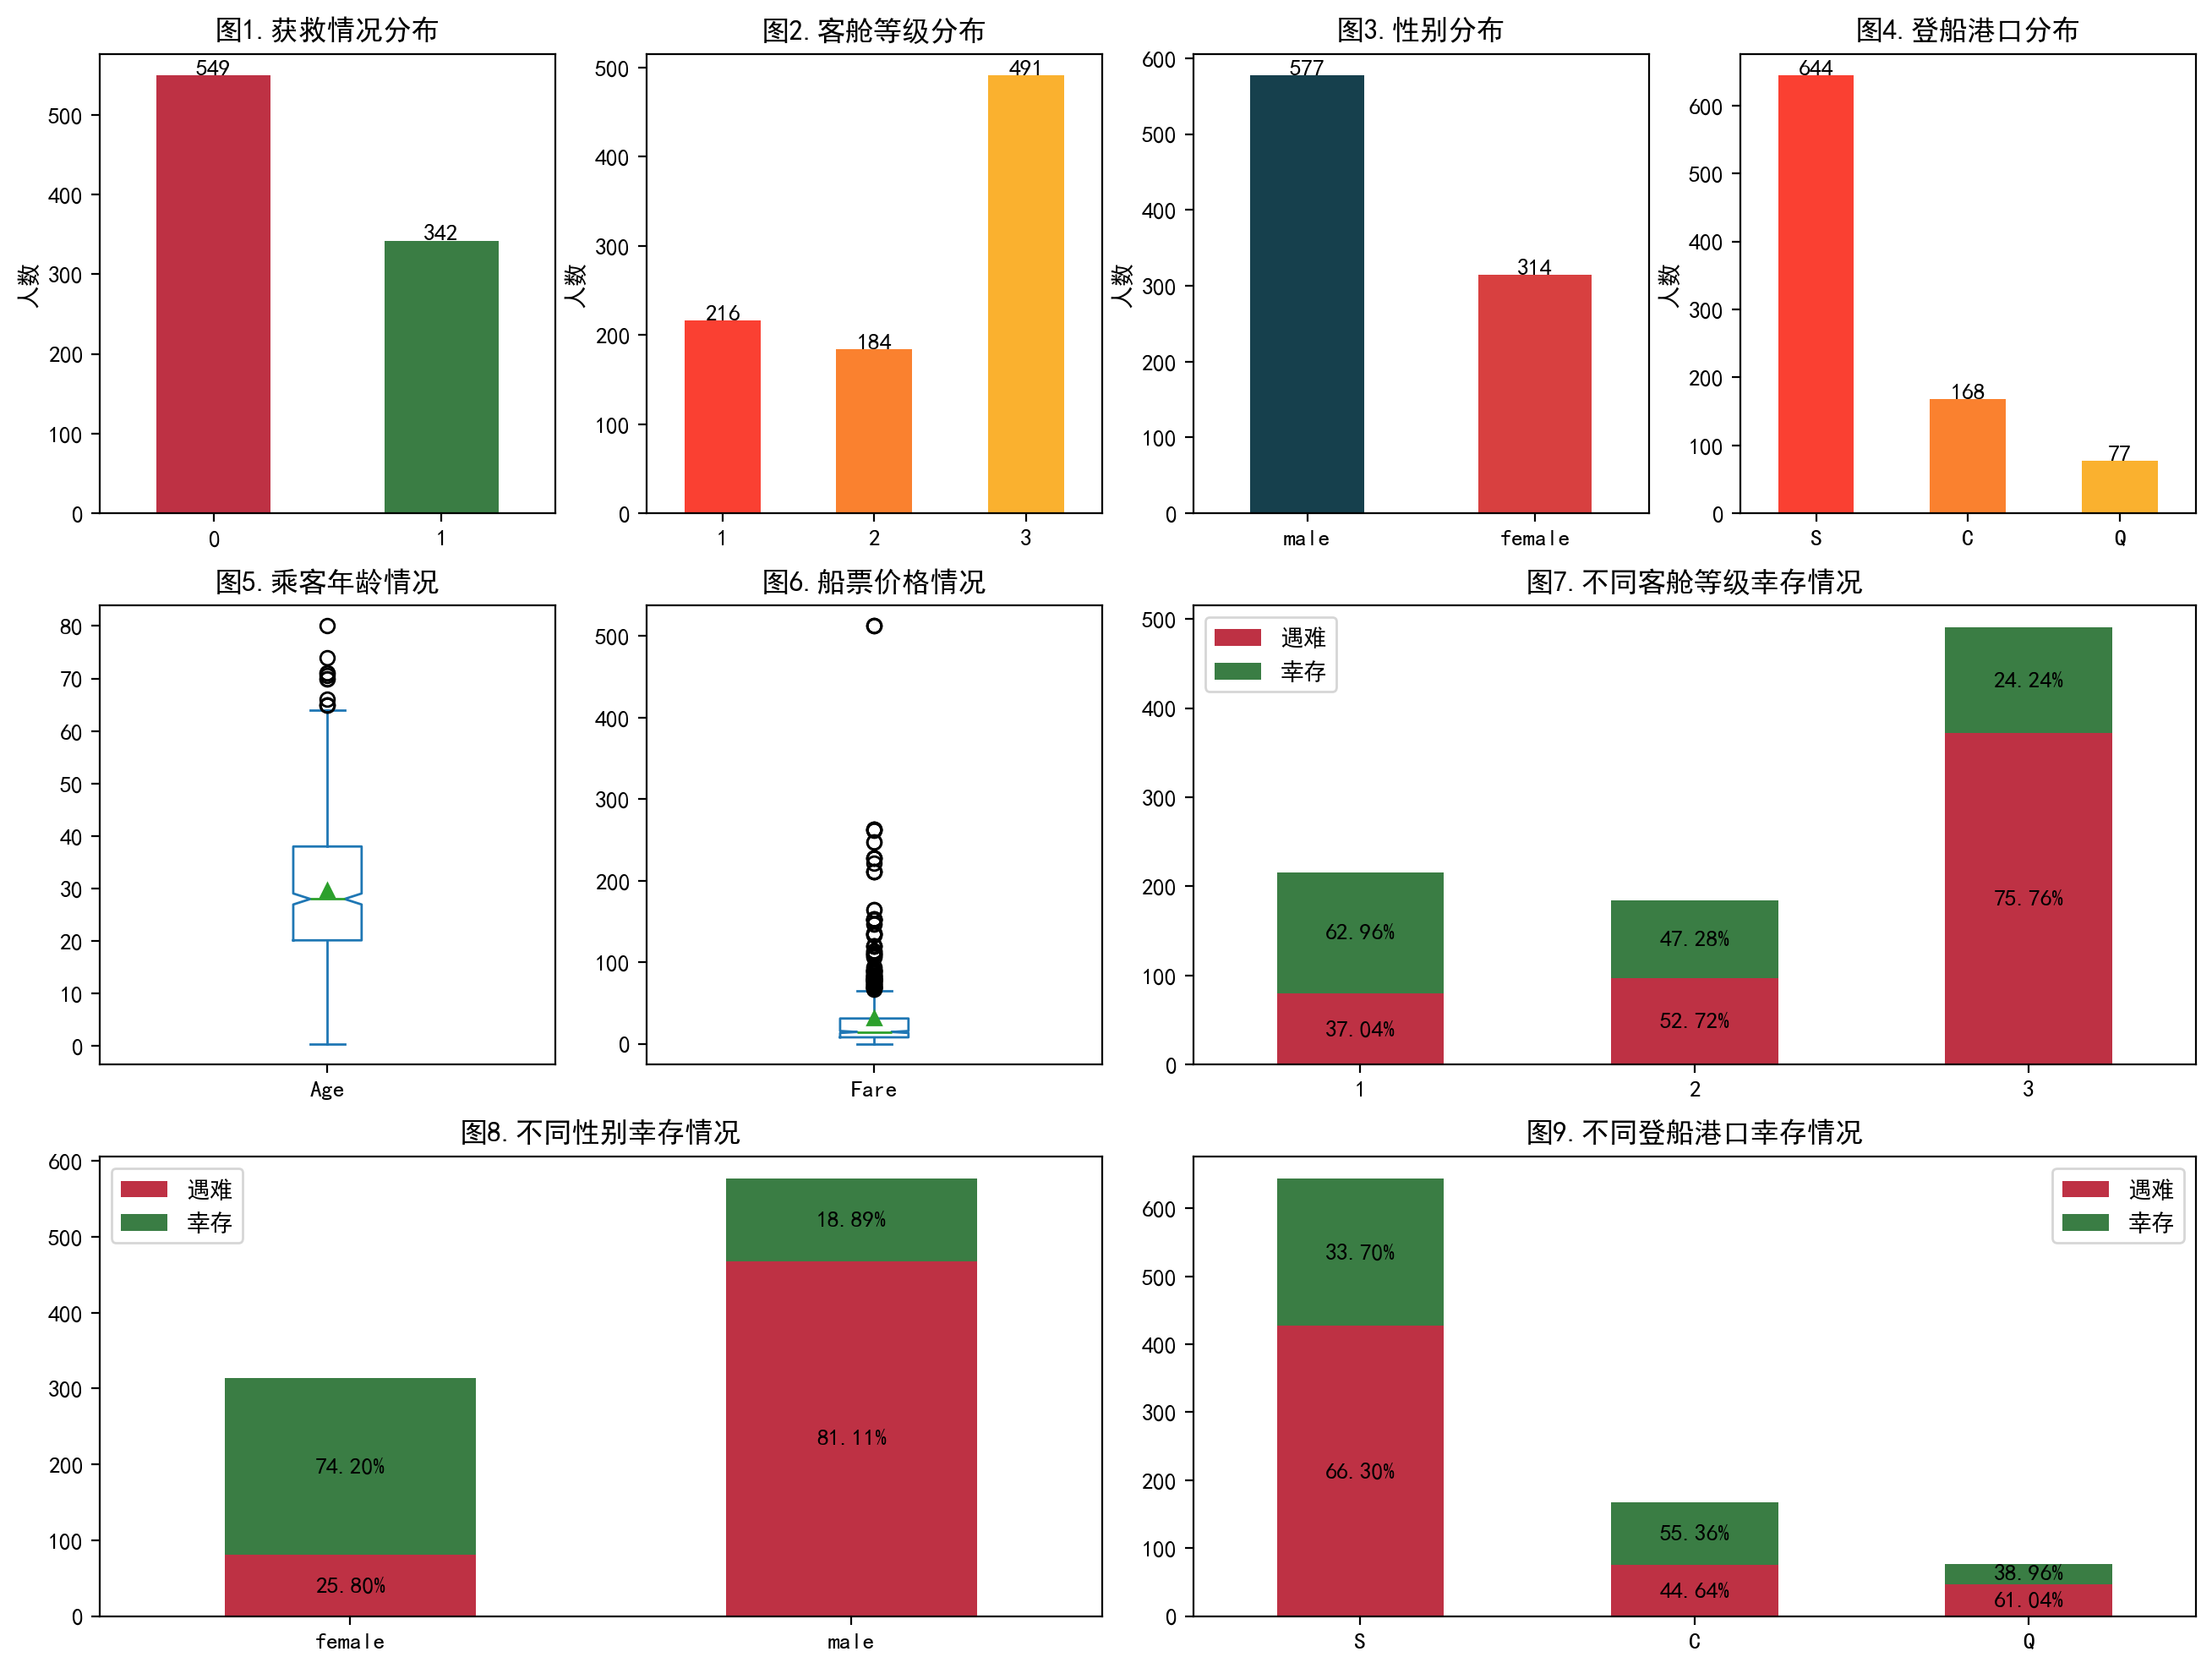

In [4]:
import matplotlib.pyplot as plt

# 修改配置添加中文字体
plt.rcParams['font.sans-serif'].insert(0, 'SimHei')
plt.rcParams['axes.unicode_minus'] = False

# 定制画布
plt.figure(figsize=(16, 12), dpi=200)

# 遇难和获救人数分布
plt.subplot(3, 4, 1)
ser = df.Survived.value_counts()
ser.plot(kind='bar', color=['#BE3144', '#3A7D44'])
plt.xticks(rotation=0)
plt.title('图1.获救情况分布')
plt.ylabel('人数')
plt.xlabel('')
for i, v in enumerate(ser):
    plt.text(i, v, v, ha='center')

# 客舱等级人数分布
plt.subplot(3, 4, 2)
ser = df.Pclass.value_counts().sort_index()
ser.plot(kind='bar', color=['#FA4032', '#FA812F', '#FAB12F'])
plt.xticks(rotation=0)
plt.ylabel('人数')
plt.xlabel('')
plt.title('图2.客舱等级分布')
for i, v in enumerate(ser):
    plt.text(i, v, v, ha='center')

# 性别人数分布
plt.subplot(3, 4, 3)
ser = df.Sex.value_counts()
ser.plot(kind='bar', color=['#16404D', '#D84040'])
plt.xticks(rotation=0)
plt.ylabel('人数')
plt.xlabel('')
plt.title('图3.性别分布')
for i, v in enumerate(ser):
    plt.text(i, v, v, ha='center')

# 登船港口人数分布
plt.subplot(3, 4, 4)
ser = df.Embarked.value_counts()
ser.plot(kind='bar', color=['#FA4032', '#FA812F', '#FAB12F'])
plt.xticks(rotation=0)
plt.ylabel('人数')
plt.xlabel('')
plt.title('图4.登船港口分布')
for i, v in enumerate(ser):
    plt.text(i, v, v, ha='center')

# 乘客年龄箱线图
plt.subplot(3, 4, 5)
df.Age.plot(kind='box', showmeans=True, notch=True)
plt.title('图5.乘客年龄情况')

# 船票价格箱线图
plt.subplot(3, 4, 6)
df.Fare.plot(kind='box', showmeans=True, notch=True)
plt.title('图6.船票价格情况')

# 不同客舱等级遇难和幸存人数分布
plt.subplot(3, 4, (7, 8))
s0 = df[df.Survived == 0].Pclass.value_counts()
s1 = df[df.Survived == 1].Pclass.value_counts()
temp = pd.DataFrame({'遇难': s0, '幸存': s1})
pcts = temp.div(temp.sum(axis=1), axis=0)
temp.plot(ax=plt.gca(), kind='bar', stacked=True, color=['#BE3144', '#3A7D44'])
for i, idx in enumerate(temp.index):
    plt.text(i, temp.at[idx, '遇难'] // 2, f'{pcts.at[idx, "遇难"]:.2%}', ha='center', va='center')
    plt.text(i, temp.at[idx, '遇难'] + temp.at[idx, '幸存'] // 2, f'{pcts.at[idx, "幸存"]:.2%}', ha='center', va='center')
plt.xticks(rotation=0)
plt.xlabel('')
plt.title('图7.不同客舱等级幸存情况')

# 不同性别遇难和幸存人数分布
plt.subplot(3, 4, (9, 10))
s0 = df[df.Survived == 0].Sex.value_counts()
s1 = df[df.Survived == 1].Sex.value_counts()
temp = pd.DataFrame({'遇难': s0, '幸存': s1})
pcts = temp.div(temp.sum(axis=1), axis=0)
temp.plot(ax=plt.gca(), kind='bar', stacked=True, color=['#BE3144', '#3A7D44'])
for i, idx in enumerate(temp.index):
    plt.text(i, temp.at[idx, '遇难'] // 2, f'{pcts.at[idx, "遇难"]:.2%}', ha='center', va='center')
    plt.text(i, temp.at[idx, '遇难'] + temp.at[idx, '幸存'] // 2, f'{pcts.at[idx, "幸存"]:.2%}', ha='center', va='center')
plt.xticks(rotation=0)
plt.xlabel('')
plt.title('图8.不同性别幸存情况')

# 不同登船港口遇难和幸存人数分布
plt.subplot(3, 4, (11, 12))
s0 = df[df.Survived == 0].Embarked.value_counts()
s1 = df[df.Survived == 1].Embarked.value_counts()
temp = pd.DataFrame({'遇难': s0, '幸存': s1})
pcts = temp.div(temp.sum(axis=1), axis=0)
temp.plot(ax=plt.gca(), kind='bar', stacked=True, color=['#BE3144', '#3A7D44'])
for i, idx in enumerate(temp.index):
    plt.text(i, temp.at[idx, '遇难'] // 2, f'{pcts.at[idx, "遇难"]:.2%}', ha='center', va='center')
    plt.text(i, temp.at[idx, '遇难'] + temp.at[idx, '幸存'] // 2, f'{pcts.at[idx, "幸存"]:.2%}', ha='center', va='center')
plt.xticks(rotation=0)
plt.xlabel('')
plt.title('图9.不同登船港口幸存情况')

plt.show()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [6]:
df['Age'] = df.Age.fillna(df.Age.median())
df['Embarked'] = df.Embarked.fillna(df.Embarked.mode()[0])
df['Cabin'] = df.Cabin.replace(r'.+', '1', regex=True).replace(np.nan, 0).astype('i8')

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Fare', 'Age']] = scaler.fit_transform(df[['Fare', 'Age']])

In [8]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

In [9]:
title_mapping = {
    'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Dr': 4, 'Rev': 5, 'Col': 6, 'Major': 7, 
    'Mlle': 8, 'Ms': 9, 'Lady': 10, 'Sir': 11, 'Jonkheer': 12, 'Don': 13, 'Dona': 14, 'Countess': 15
}
df['Title'] = df['Name'].map(
    lambda x: x.split(',')[1].split('.')[0].strip()
).map(title_mapping).fillna(-1)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [10]:
df.drop(columns=['Name', 'SibSp', 'Parch', 'Ticket'], inplace=True)

In [11]:
from sklearn.model_selection import train_test_split

X, y = df.drop(columns='Survived'), df.Survived
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.9, random_state=3)

* 尝试1 逻辑回归模型

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(penalty='l1', tol=1e-6, solver='liblinear')
model.fit(X_train, y_train)
y_pred = model.predict(X_valid)
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.80      0.84        56
           1       0.72      0.82      0.77        34

    accuracy                           0.81        90
   macro avg       0.80      0.81      0.80        90
weighted avg       0.82      0.81      0.81        90



* 尝试2 XGBoost

In [14]:
import xgboost as xgb

# 将数据处理成数据集格式DMatrix格式
dm_train = xgb.DMatrix(X_train, y_train)
dm_valid = xgb.DMatrix(X_valid)

# 设置模型参数
params = {
    'booster': 'gbtree',             # 用于训练的基学习器类型
    'objective': 'binary:logistic',  # 指定模型的损失函数
    'gamma': 0.1,                    # 控制每次分裂的最小损失函数减少量
    'max_depth': 10,                 # 决策树最大深度
    'lambda': 0.5,                   # L2正则化权重
    'subsample': 0.8,                # 控制每棵树训练时随机选取的样本比例
    'colsample_bytree': 0.8,         # 用于控制每棵树或每个节点的特征选择比例
    'eta': 0.05,                     # 学习率
    'seed': 3,                       # 设置随机数生成器的种子
    'nthread': 16,                   # 指定了训练时并行使用的线程数
}

model = xgb.train(params, dm_train, num_boost_round=200)
y_pred = model.predict(dm_valid)
# 将预测的概率转换为类别标签
y_pred_label = (y_pred > 0.5).astype('i8')
print(classification_report(y_valid, y_pred_label))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89        56
           1       0.84      0.79      0.82        34

    accuracy                           0.87        90
   macro avg       0.86      0.85      0.86        90
weighted avg       0.87      0.87      0.87        90



模型评估，

In [15]:
test = pd.read_csv('data/test.csv', index_col='PassengerId')
# 处理缺失值
test['Age'] = test.Age.fillna(test.Age.median())
test['Fare'] = test.Fare.fillna(test.Fare.median())
test['Embarked'] = test.Embarked.fillna(test.Embarked.mode()[0])
test['Cabin'] = test.Cabin.replace(r'.+', '1', regex=True).replace(np.nan, 0).astype('i8')
# 特征缩放
test[['Fare', 'Age']] = scaler.fit_transform(test[['Fare', 'Age']])
# 处理类别
test = pd.get_dummies(test, columns=['Sex', 'Embarked'], drop_first=True)
# 特征构造
test['Title'] = test['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip()).map(title_mapping).fillna(-1)
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1
# 删除多余特征
test.drop(columns=['Name', 'Ticket', 'SibSp', 'Parch'], inplace=True)

# 逻辑回归模型
# passenger_id, X_test = test.index, test
# XGBoost模型
passenger_id, X_test = test.index, xgb.DMatrix(test)

# y_test_pred = model.predict(X_test)
# XGoost模型 - 将预测的概率转换成类别标签
y_test_pred = (model.predict(X_test) > 0.5).astype('i8')

# 生成提交文件
result = pd.DataFrame({
    'PassengerId': passenger_id,
    'Survived': y_test_pred
})
result.to_csv('submission.csv', index=False)